# **Email Spam Detection with Machine Learning**

**1. Problem Statement**



## Objective
The goal of this project is to build a machine learning model that can classify messages as:

- Spam (Unwanted message)
- Ham (Legitimate message)

The dataset contains SMS messages labeled as spam or ham.

## Machine Learning Task

This is a:

**Binary Classification Problem**

Output Classes:

- Spam = 1
- Ham = 0

**2. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

**3. Load the Dataset**

In [ ]:
df = pd.read_csv("spam (1).csv", encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


**4. Data Understanding**

In [ ]:
df.shape

(5572, 5)

In [ ]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


**5. Data Cleaning**

In [ ]:
#remove unnecessary columns
df.drop(
    columns = ["Unnamed: 2","Unnamed: 3","Unnamed: 4"],
    inplace = True
)

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#rename columns
df.rename(
    columns={
        "v1" : "label",
        "v2" : "message"
    },
    inplace = True
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#check duplicates
df.duplicated().sum()

np.int64(403)

In [ ]:
#remove duplicates
df.drop_duplicates(inplace = True, keep = "first")

In [ ]:
df.shape

(5169, 2)

**6. Exploratory Data Analysis (EDA)**

In [ ]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


*Visualization*

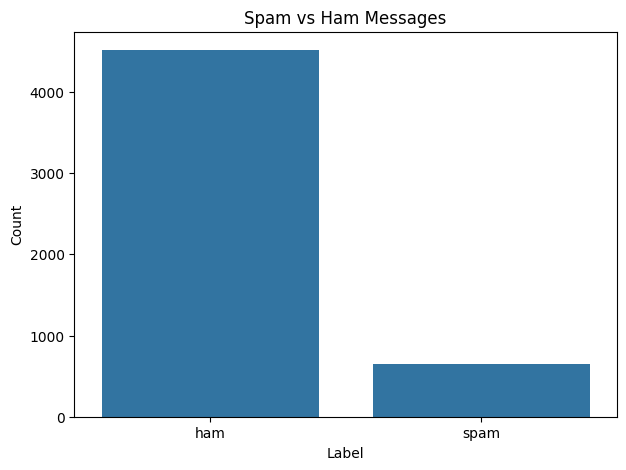

In [ ]:
plt.figure(figsize = (7,5))

sns.countplot(x = df['label'])
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Spam vs Ham Messages")

plt.show()

Usually ham messages are much higher than spam messages.
This indicates class imbalance.

**7. Label Encoding**

In [ ]:
df['label'] = df['label'].map({
    "ham" : 0,
    "spam" : 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


**8. Feature Engineering**

Spam messages tend to be longer.

In [ ]:
#message length
df['num_characters'] = df['message'].apply(len)

df.head()

,label,message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
#number of words
df['num_words'] = df['message'].apply(
    lambda x: len(x.split())
    )

#number of sentences
df['nun_sentences'] = df['message'].apply(
    lambda x: len(re.split(r'[.!?]+', x)) - 1
    )

df.head()

,label,message,num_characters,num_words,nun_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,0,U dun say so early hor... U c already then say...,49,11,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0


In [ ]:
df.describe()

,label,num_characters,num_words,nun_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,15.340685,1.846779
std,0.332253,58.236293,11.068488,1.745441
min,0.000000,2.000000,1.000000,0.000000
25%,0.000000,36.000000,7.000000,1.000000
50%,0.000000,60.000000,12.000000,2.000000
75%,0.000000,117.000000,22.000000,3.000000
max,1.000000,910.000000,171.000000,39.000000


In [ ]:
#comparing ham vs spam messages
df.groupby('label')[[
    'num_characters',
    'num_words',
    'nun_sentences'
]].mean()

,num_characters,num_words,nun_sentences
label,,,
0,70.459256,14.134632,1.692648
1,137.891271,23.681470,2.912711


Spam messages generally contain:

- More characters
- More words
- More sentences

than ham messages.

**9. Visualizations**

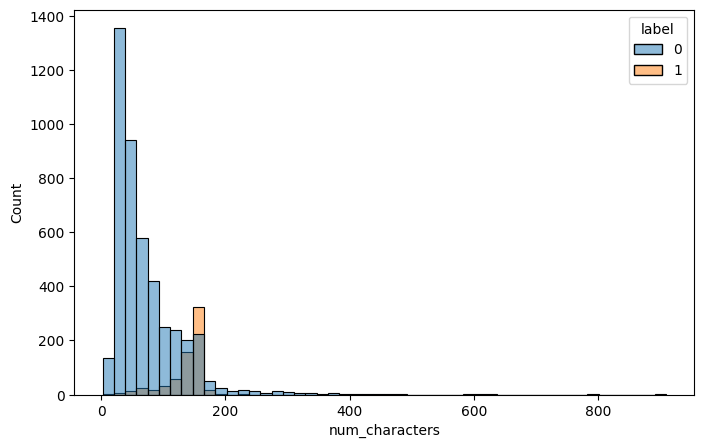

In [ ]:
#distribution of Message Length

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='num_characters',
    hue='label',
    bins=50
)

plt.show()

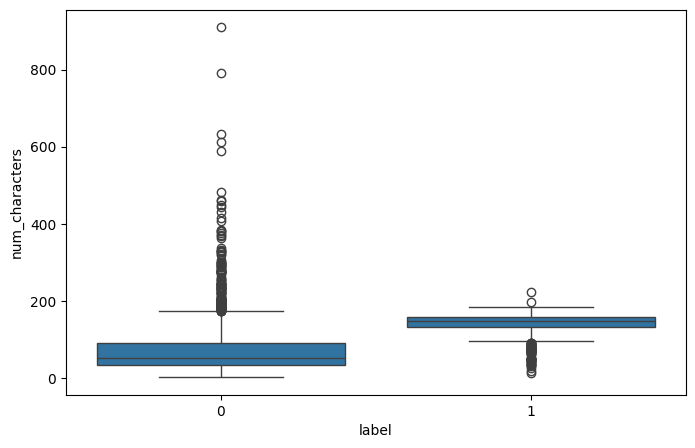

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='num_characters',
    data=df
)

plt.show()

Dots above the whiskers are outliers. They represents that the message is too long than normal

**10. Text Preprocessing**

**Why?**

**Raw text contains:**

punctuation, special characters, stopwords, uppercase letters

These don't help prediction.

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# create cleaning function
from nltk.corpus import stopwords

def transform_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    words = text.split()

    words = [
        word
        for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

#apply function
df['transformed_message'] = df['message'].apply(transform_text)

df.head()

,label,message,num_characters,num_words,nun_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah dont think goes usf lives around though


**11. Convert Text to Numbers**

Machine learning cannot understand words. Therefore we will use TF-IDF as it converts words into numerical features.

In [ ]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(
    df['transformed_message']
).toarray()

y = df['label']

**12. Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**13. Model Building**

Model: **Logistic Regression**

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
#evalution

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

Accuracy: 0.9526112185686654
Precision: 0.9363636363636364
Recall: 0.7103448275862069
F1 Score: 0.807843137254902


**14. Predict New Messages**

In [ ]:
test_messages = [
    "FREE entry into our prize draw",
    "Claim your cash reward now",
    "WINNER!! Call now to collect prize",
    "URGENT! Your account has been selected"
]

for msg in test_messages:

    # Preprocess
    clean = transform_text(msg)

    # TF-IDF Vectorization
    vec = tfidf.transform([clean])

    # Prediction
    prediction = lr.predict(vec)[0]

    # Probabilities
    prob = lr.predict_proba(vec)

    ham_prob = prob[0][0] * 100
    spam_prob = prob[0][1] * 100

    print("="*60)
    print("Original Message :", msg)
    print("Processed Message:", clean)

    print("\nHam Probability : {:.2f}%".format(ham_prob))
    print("Spam Probability: {:.2f}%".format(spam_prob))

    if prediction == 1:
        print("\nPrediction: SPAM")
    else:
        print("\nPrediction: HAM")

    print("="*60)
    print()

Original Message : FREE entry into our prize draw
Processed Message: free entry prize draw

Ham Probability : 25.29%
Spam Probability: 74.71%

Prediction: SPAM

Original Message : Claim your cash reward now
Processed Message: claim cash reward

Ham Probability : 38.14%
Spam Probability: 61.86%

Prediction: SPAM

Original Message : WINNER!! Call now to collect prize
Processed Message: winner call collect prize

Ham Probability : 29.96%
Spam Probability: 70.04%

Prediction: SPAM

Original Message : URGENT! Your account has been selected
Processed Message: urgent account selected

Ham Probability : 59.09%
Spam Probability: 40.91%

Prediction: HAM



## Conclusion

In this project, I built a Spam Detection model using Logistic Regression. I cleaned the data, analyzed it, and converted the text messages into numerical form using TF-IDF. The model was trained to identify whether a message is spam or ham. The results show that the model can correctly classify most messages and can be used to filter unwanted spam messages.